## 📊 Dataset Description (PatchCamelyon)

The dataset used is **PatchCamelyon (PCam)** from Kaggle.

- It consists of histopathology (Real medical slides from breast cancer patients) image patches for cancer detection.  
- Each image is **96 × 96 pixels (RGB)**.  
- Specifically: lymph node tissue
- Extracted from a bigger dataset called CAMELYON16

### 🔢 Classification Task
This is a **binary classification dataset**:
- **0 → Negative (no tumor)**
- **1 → Positive (metastatic tumor present)**  
The label depends only on the center area of the image.
Even if edges have tumor, it doesn’t count

### 📦 Dataset Size
The dataset is originally large (~300,000 images), but a subset was used:
- **Training:** 40,000 images  
- **Validation:** 10,000 images  
- **Testing:** 10,000 images  

### 💾 Data Format
- Images are stored in **HDF5 (.h5)** format  
- Requires custom loading using **h5py**

### 🔄 Data Augmentation
To improve generalization, the following techniques were applied:
- Random flipping  
- Rotation  


---

## 🧠 CNN Model Description

A custom **Convolutional Neural Network (CNN)** was built using **PyTorch**.

### 🏗️ Architecture
The model consists of **4 convolutional blocks**, each including:
- Convolution layer  
- Batch Normalization  
- ReLU activation  
- Max Pooling  

### 🔗 Fully Connected Layers
After feature extraction:
- Flattening layer  
- Fully connected layer (**512 units**)  
- Dropout (**0.5**) for regularization  
- Final output layer (**2 neurons for binary classification**)  

### ⚙️ Key Components
- **Batch Normalization:** Stabilizes training and improves performance  
- **Dropout:** Reduces overfitting  

### 📉 Training Setup
- **Loss Function:** CrossEntropyLoss  
- **Optimizer:** Adam  
- **Learning Rate Scheduler:** StepLR  

### 🎯 Model Capability
The network successfully learns **spatial features from medical images** for accurate classification.

In [4]:
# Step 1: Install libraries

!pip install -q torchsummary h5py kagglehub

In [5]:
# Step 1B: Import libraries

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from torchsummary import summary

import kagglehub

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Torch version:", torch.__version__)

Using device: cuda
Torch version: 2.10.0+cu128


In [6]:
# Step 2: Download dataset from Kaggle

path = kagglehub.dataset_download("andrewmvd/metastatic-tissue-classification-patchcamelyon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'metastatic-tissue-classification-patchcamelyon' dataset.
Path to dataset files: /kaggle/input/metastatic-tissue-classification-patchcamelyon


In [7]:
# Step 3: See what files are inside the dataset folder

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    for file in files:
        print("   ", file)

Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Metadata
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Metadata/Metadata
    valid_metadata.csv
    train_metadata.csv
    test_metadata.csv
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Labels
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Labels/Labels
    camelyonpatch_level_2_split_train_y.h5
    camelyonpatch_level_2_split_valid_y.h5
    camelyonpatch_level_2_split_test_y.h5
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/camelyonpatch_level_2_split_train_mask
    camelyonpatch_level_2_split_train_mask.h5
Folder: /kaggle/input/metastatic-tissue-classification-patchcamelyon/pcam
    training_split.h5
    test_split.h5
    validation_split.h5


In [9]:
# Step 4: Create a custom Dataset class for H5 files

class PCAMDataset(Dataset):
    def __init__(self, x_file, y_file, transform=None):
        self.x_file = x_file
        self.y_file = y_file
        self.transform = transform

        # Open H5 files
        self.x_data = h5py.File(self.x_file, 'r')
        self.y_data = h5py.File(self.y_file, 'r')

        # Get dataset keys automatically
        self.x_key = list(self.x_data.keys())[0]
        self.y_key = list(self.y_data.keys())[0]

        self.images = self.x_data[self.x_key]
        self.labels = self.y_data[self.y_key]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]              # shape should be (96, 96, 3)
        label = self.labels[idx][0]           # label becomes 0 or 1

        image = image.astype(np.uint8)

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
# Step 5: Define dataset file paths

train_x_path = os.path.join(path, "pcam", "training_split.h5")
val_x_path   = os.path.join(path, "pcam", "validation_split.h5")
test_x_path  = os.path.join(path, "pcam", "test_split.h5")

train_y_path = os.path.join(path, "Labels", "Labels", "camelyonpatch_level_2_split_train_y.h5")
val_y_path   = os.path.join(path, "Labels", "Labels", "camelyonpatch_level_2_split_valid_y.h5")
test_y_path  = os.path.join(path, "Labels", "Labels", "camelyonpatch_level_2_split_test_y.h5")

print("Train X:", train_x_path)
print("Train Y:", train_y_path)
print("Validation X:", val_x_path)
print("Validation Y:", val_y_path)
print("Test X:", test_x_path)
print("Test Y:", test_y_path)

Train X: /kaggle/input/metastatic-tissue-classification-patchcamelyon/pcam/training_split.h5
Train Y: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_train_y.h5
Validation X: /kaggle/input/metastatic-tissue-classification-patchcamelyon/pcam/validation_split.h5
Validation Y: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_valid_y.h5
Test X: /kaggle/input/metastatic-tissue-classification-patchcamelyon/pcam/test_split.h5
Test Y: /kaggle/input/metastatic-tissue-classification-patchcamelyon/Labels/Labels/camelyonpatch_level_2_split_test_y.h5


In [11]:
# Step 6: Define transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [12]:
# Step 7: Create dataset objects

train_dataset = PCAMDataset(train_x_path, train_y_path, transform=train_transform)
val_dataset   = PCAMDataset(val_x_path, val_y_path, transform=test_transform)
test_dataset  = PCAMDataset(test_x_path, test_y_path, transform=test_transform)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

sample_image, sample_label = train_dataset[0]
print("Sample image shape:", sample_image.shape)
print("Sample label:", sample_label)

Train dataset size: 262144
Validation dataset size: 32768
Test dataset size: 32768
Sample image shape: torch.Size([3, 96, 96])
Sample label: [[0]]


In [13]:
# Step 8: Reduce dataset size

from torch.utils.data import Subset
import numpy as np

# Fix randomness for reproducibility
np.random.seed(42)

# Select random indices
train_indices = np.random.choice(len(train_dataset), 40000, replace=False)
test_indices  = np.random.choice(len(test_dataset), 10000, replace=False)

# Create subsets
train_subset = Subset(train_dataset, train_indices)
test_subset  = Subset(test_dataset, test_indices)

# Keep validation full or smaller (optional)
val_subset = Subset(val_dataset, np.random.choice(len(val_dataset), 10000, replace=False))

print("New Train size:", len(train_subset))
print("New Val size:", len(val_subset))
print("New Test size:", len(test_subset))

New Train size: 40000
New Val size: 10000
New Test size: 10000


In [14]:
# Step 9: Create DataLoaders

BATCH_SIZE = 128

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 313
Val batches: 79
Test batches: 79


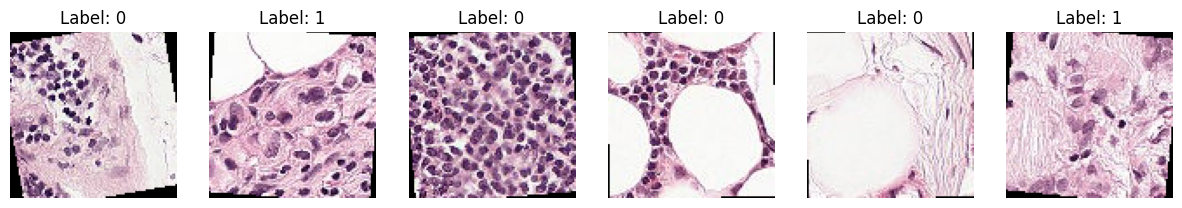

In [15]:
# Step 10: Show sample images

def show_images(loader):
    images, labels = next(iter(loader))

    fig, axes = plt.subplots(1, 6, figsize=(15, 5))

    for i in range(6):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5  # unnormalize

        axes[i].imshow(img)
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')

    plt.show()

show_images(train_loader)

In [16]:
# Step 11: Define CNN model

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 24 -> 12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # 12 -> 6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CustomCNN().to(device)
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [17]:
# Step 12: Model summary

summary(model, (3, 96, 96))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 96, 96]             896
       BatchNorm2d-2           [-1, 32, 96, 96]              64
              ReLU-3           [-1, 32, 96, 96]               0
         MaxPool2d-4           [-1, 32, 48, 48]               0
            Conv2d-5           [-1, 64, 48, 48]          18,496
       BatchNorm2d-6           [-1, 64, 48, 48]             128
              ReLU-7           [-1, 64, 48, 48]               0
         MaxPool2d-8           [-1, 64, 24, 24]               0
            Conv2d-9          [-1, 128, 24, 24]          73,856
      BatchNorm2d-10          [-1, 128, 24, 24]             256
             ReLU-11          [-1, 128, 24, 24]               0
        MaxPool2d-12          [-1, 128, 12, 12]               0
           Conv2d-13          [-1, 256, 12, 12]         295,168
      BatchNorm2d-14          [-1, 256,

In [18]:
# Step 13: Loss function, optimizer, and scheduler

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler: <torch.optim.lr_scheduler.StepLR object at 0x7d0a82249940>


In [19]:
# Step 14: Training and validation function

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=5):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # -------------------- Training --------------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.view(-1).long().to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct / total

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # -------------------- Validation --------------------
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.view(-1).long().to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader)
        epoch_val_acc = 100 * val_correct / val_total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
# Step 15: Train the model

EPOCHS = 5

train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=EPOCHS
)

Epoch [1/5] Train Loss: 0.5765, Train Acc: 80.77% | Val Loss: 0.4212, Val Acc: 81.92%
Epoch [2/5] Train Loss: 0.3732, Train Acc: 84.44% | Val Loss: 0.4053, Val Acc: 83.16%
Epoch [3/5] Train Loss: 0.3533, Train Acc: 85.50% | Val Loss: 0.4062, Val Acc: 81.92%
Epoch [4/5] Train Loss: 0.3106, Train Acc: 87.37% | Val Loss: 0.3676, Val Acc: 84.36%
Epoch [5/5] Train Loss: 0.3002, Train Acc: 87.93% | Val Loss: 0.3628, Val Acc: 84.39%


In [21]:
# Step 16: Continue training for more epochs

MORE_EPOCHS = 50

more_train_losses, more_val_losses, more_train_acc, more_val_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=MORE_EPOCHS
)

# Combine results
train_losses += more_train_losses
val_losses += more_val_losses
train_accuracies += more_train_acc
val_accuracies += more_val_acc

Epoch [1/50] Train Loss: 0.2928, Train Acc: 88.32% | Val Loss: 0.3693, Val Acc: 83.56%
Epoch [2/50] Train Loss: 0.2800, Train Acc: 88.76% | Val Loss: 0.3902, Val Acc: 83.01%
Epoch [3/50] Train Loss: 0.2770, Train Acc: 88.97% | Val Loss: 0.3735, Val Acc: 83.71%
Epoch [4/50] Train Loss: 0.2762, Train Acc: 88.99% | Val Loss: 0.3749, Val Acc: 83.62%
Epoch [5/50] Train Loss: 0.2758, Train Acc: 89.19% | Val Loss: 0.3837, Val Acc: 83.61%
Epoch [6/50] Train Loss: 0.2738, Train Acc: 89.00% | Val Loss: 0.3782, Val Acc: 83.60%
Epoch [7/50] Train Loss: 0.2761, Train Acc: 88.83% | Val Loss: 0.3821, Val Acc: 83.74%
Epoch [8/50] Train Loss: 0.2753, Train Acc: 89.06% | Val Loss: 0.3803, Val Acc: 83.59%
Epoch [9/50] Train Loss: 0.2743, Train Acc: 88.98% | Val Loss: 0.3853, Val Acc: 83.57%
Epoch [10/50] Train Loss: 0.2756, Train Acc: 88.99% | Val Loss: 0.3780, Val Acc: 83.63%
Epoch [11/50] Train Loss: 0.2760, Train Acc: 88.80% | Val Loss: 0.3826, Val Acc: 83.73%
Epoch [12/50] Train Loss: 0.2743, Train A

KeyboardInterrupt: 

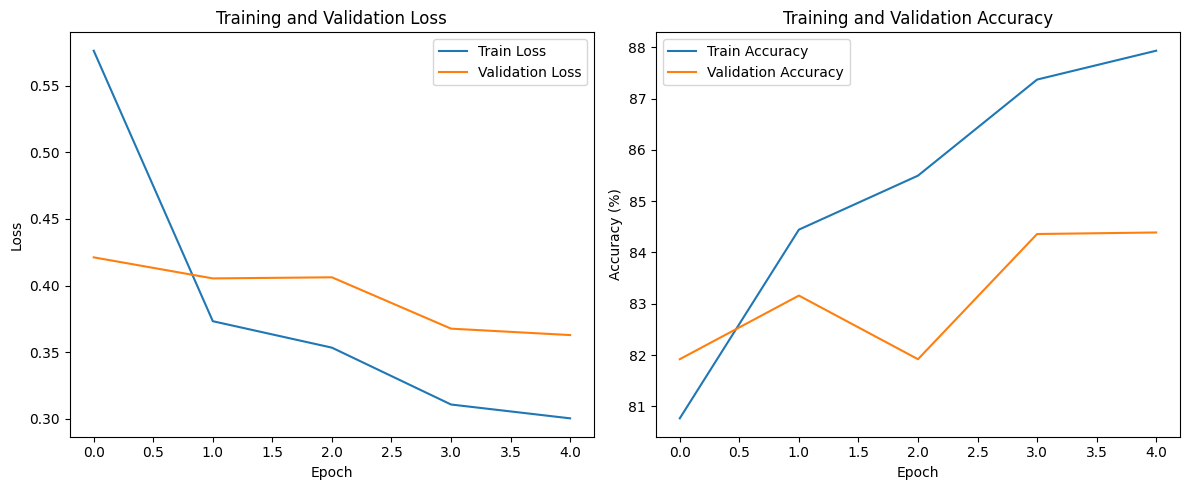

In [22]:
# Step 17: Plot loss and accuracy curves

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Step 18: Test set evaluation

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.view(-1).long().to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 81.54%


In [25]:
# Step 19: Precision, Recall, F1-score

print(classification_report(all_labels, all_preds, target_names=['negative', 'positive']))

              precision    recall  f1-score   support

    negative       0.77      0.90      0.83      4998
    positive       0.88      0.73      0.80      5002

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



In [26]:
# Step 20: Confusion matrix

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4480  518]
 [1328 3674]]


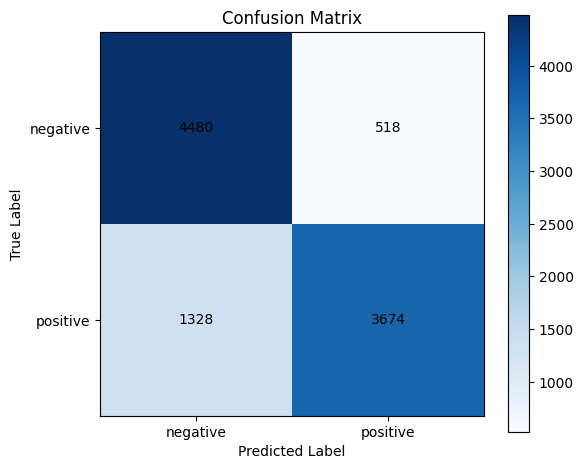

In [27]:
# Step 20B: Plot confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['negative', 'positive'])
plt.yticks(tick_marks, ['negative', 'positive'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [28]:
# Step 21: Save trained model

torch.save(model.state_dict(), " CNN_23-50251-1 FAHIMA ISLAM.pth")
print("Model saved successfully as  CNN_23-50251-1 FAHIMA ISLAM.pth")

Model saved successfully as  CNN_23-50251-1 FAHIMA ISLAM.pth


Result summary
Training dataset size: 40,000
Validation dataset size: 10,000
Testing dataset size: 10,000
Final test accuracy: 81.54%
Classification report
Negative class
Precision: 0.77
Recall: 0.90
F1-score: 0.83
Positive class
Precision: 0.88
Recall: 0.73
F1-score: 0.80
Overall accuracy: 0.82
Macro average F1-score: 0.81
Weighted average F1-score: 0.81
Confusion matrix
[[4480  518]
 [1328 3674]]

This means:

4480 negative samples were correctly classified as negative
3674 positive samples were correctly classified as positive
518 negative samples were wrongly classified as positive
1328 positive samples were wrongly classified as negative

The custom CNN model achieved a test accuracy of 81.54% on the PatchCamelyon dataset subset. Training accuracy improved steadily across epochs, while validation accuracy increased initially and then stabilized around 84%, indicating that the model learned useful image features without severe overfitting. The loss curves also showed a clear reduction in training loss and a moderate reduction in validation loss.

From the classification report, the model performed better on the negative class in terms of recall (0.90), meaning it was able to correctly identify most negative samples. For the positive class, precision was higher (0.88), but recall was lower (0.73), which indicates that the model missed some positive metastatic tissue samples.

The confusion matrix further confirms this pattern, as the number of false negatives for the positive class was higher than the number of false positives. This suggests that although the model performs reasonably well overall, it is still less sensitive to positive cases. In medical image classification, reducing false negatives is especially important, so future improvements could include deeper architectures, class balancing techniques, data augmentation tuning, and longer controlled training with early stopping.

Based on recall and F1-score, the best-performing class was the negative class, with recall 0.90 and F1-score 0.83. The worst-performing class was the positive class, with recall 0.73 and F1-score 0.80. This indicates that the model was more effective at identifying non-metastatic tissue patches than metastatic tissue patches.

In this project, a custom CNN was developed to classify histopathology image patches into negative and positive metastatic tissue classes. The model was trained on a subset of the PatchCamelyon dataset using PyTorch, with batch normalization and dropout included for improved generalization. The final model achieved 81.54% test accuracy and produced balanced overall precision, recall, and F1-score values. Although the model showed good performance, the positive class remained more difficult to detect. Future work could improve performance by using a deeper CNN, transfer learning, hyperparameter tuning, and class-sensitive optimization techniques.